In [1]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from fvd_models import Encoder, Decoder, HybridAEVAE
import numpy as np
import torch
import skdim

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 512
obs_shape = 64
data_steps = 40000 # 20k
num_epochs = 50
steps_per_epoch = 500 # 200
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
# env = RandomColorReplace(env)
# env = gym.make('Pendulum-v1', render_mode='rgb_array')
env = DomainRandomization(env, {"LINK_LENGTH_1": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0]), "LINK_LENGTH_2": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0])})
# env = DomainRandomization(env, {"g": (5.0, 20.0)})
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)

In [2]:
obs, _ = env.reset()

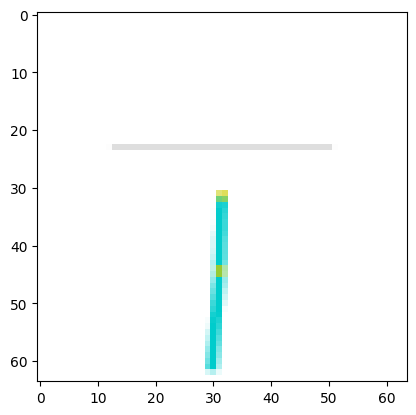

In [3]:
plt.imshow(obs[:, :, :3] / 255)

In [4]:
samples = random_sample_single_env(env, num_steps=data_steps)
for i in range(data_steps):
    buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

In [5]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)

In [6]:
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        reconstruction = decoder(latent)
        loss = torch.nn.functional.mse_loss(reconstruction, obs)
        loss.backward()
        opt.step()
        opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)

5000
10000
15000
20000
25000


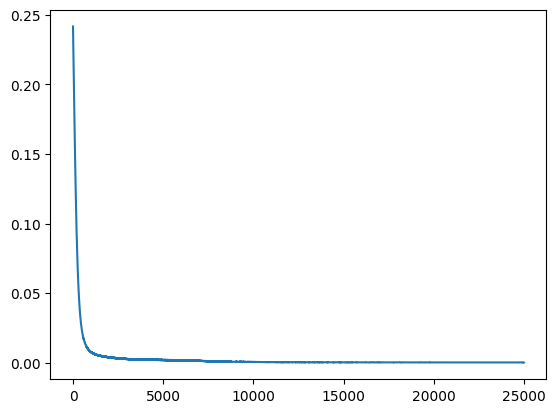

In [7]:
plt.plot(losses)


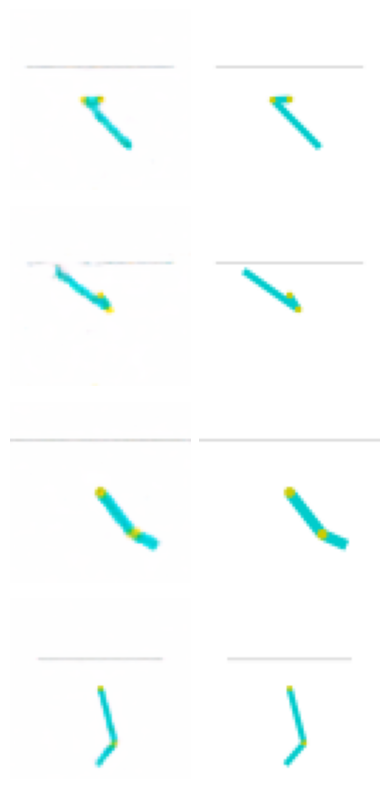

In [8]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
fig.savefig("direct_dim.png")

In [9]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 6.464688696532538 +- 0.08388639639390039
Image ID: 9.605002472381663 +- 0.1599111042333757


5000
10000
15000
20000
25000


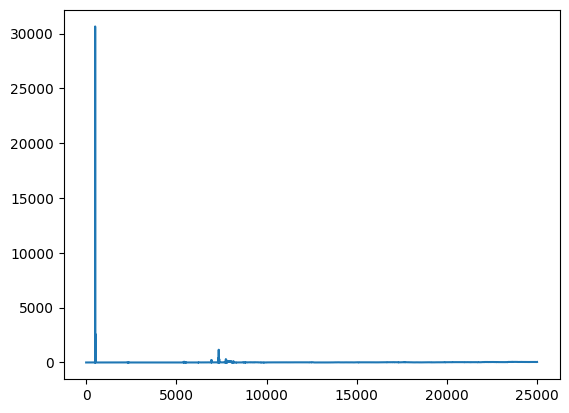

In [10]:
intrinsic_dim = round(np.mean(latent_ID))
double_autoencoder = HybridAEVAE(encoder, decoder, latent_dim, intrinsic_dim, penalty_coef=1e-5).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)
int_scheduler = torch.optim.lr_scheduler.ExponentialLR(int_opt, gamma=0.97)
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(512)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        loss = double_autoencoder.reconstruction_loss(obs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(double_autoencoder.parameters(), 1.0)
        int_opt.step()
        int_opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    int_scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)
plt.plot(losses)

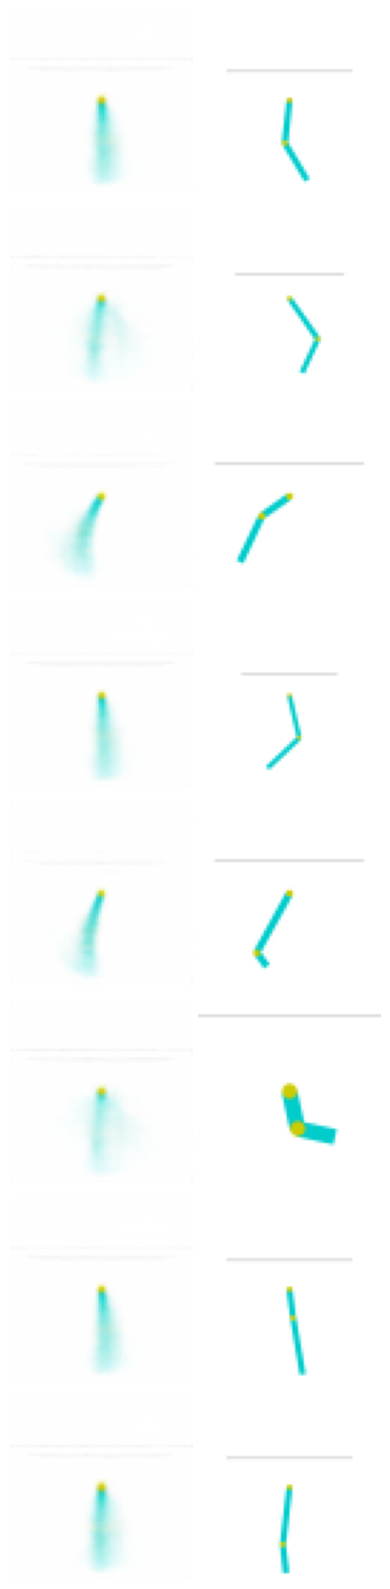

tensor([[ 0.3430, -0.1875,  0.7500,  0.1648,  0.2235, -0.4375],
        [ 0.3430, -0.1875,  0.7500,  0.1648,  0.2235, -0.5000],
        [-0.3764,  2.5275,  0.0120, -0.4946, -0.3222,  1.1413],
        [ 0.3430, -0.1875,  0.7500,  0.1648,  0.2235, -0.5000],
        [ 0.1679,  0.9419,  0.2567, -0.4816, -0.5318,  0.2396],
        [ 0.3430, -0.1875,  0.7500,  0.1648,  0.2235, -0.5000],
        [ 0.3430, -0.2500,  1.0000,  0.1648,  0.2235, -0.5000],
        [ 0.3430, -0.1875,  0.7500,  0.1648,  0.2235, -0.4375]],
       device='cuda:0', grad_fn=<SliceBackward0>)


In [11]:
plt.close("all")
%matplotlib inline
num_img = 8
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
int_latent = double_autoencoder.double_encode(obs)
reconstruction = double_autoencoder.double_decode(int_latent)
for i in range(num_img):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
print(int_latent[:num_img, intrinsic_dim:])

In [12]:
# plt.close("all")
# from matplotlib.widgets import Slider
# %matplotlib widget

# def decode(intrinsic):
#     intrinsic_tensor = torch.tensor(intrinsic).cuda()
#     reconstruction = double_autoencoder.double_decode(intrinsic_tensor)
#     reconstruction = to_numpy(reconstruction[0].transpose(-3, -1))
#     return reconstruction[:, :, :3], reconstruction[:, :, 3:]

# intrinsic = double_autoencoder.double_encode(obs)
# intrinsic = to_numpy(intrinsic[0])

# plt.figure()
# img = decode(intrinsic)
# f, axs = plt.subplots(1, 2)
# img_handle1 = axs[0].imshow(img[0])
# img_handle2 = axs[1].imshow(img[1])

# plt.subplots_adjust(left=0.25, bottom=0.35)

# slider_axes = []
# sliders = []
# for i in range(intrinsic_dim):
#     ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
#     slider_axes.append(ax)
#     slider = Slider(ax, f'z{i+1}', intrinsic[i]-20.0, intrinsic[i]+20.0, valinit=intrinsic[i])
#     sliders.append(slider)

# def update(val):
#     for i, slider in enumerate(sliders):
#         intrinsic[i] = slider.val
#     img = decode(intrinsic)
#     img_handle1.set_data(img[0])
#     img_handle2.set_data(img[1])
#     plt.draw()

# for slider in sliders:
#     slider.on_changed(update)

# plt.show()

In [13]:
# plt.close("all")

# intrinsic = double_autoencoder.double_encode(obs)
# intrinsic_base = to_numpy(intrinsic[0])
# intrinsic_base = np.zeros_like(intrinsic_base) # for VAE
# u, s, v = np.linalg.svd(to_numpy(intrinsic), full_matrices=False)
# print(s)
# print(v)
# f, axs = plt.subplots(1, 2)

# img = decode(intrinsic_base)
# img_handle1 = axs[0].imshow(img[0])
# img_handle2 = axs[1].imshow(img[1])

# plt.subplots_adjust(left=0.25, bottom=0.35)

# slider_axes = []
# sliders = []
# for i in range(intrinsic_dim):
#     ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
#     slider_axes.append(ax)
#     slider = Slider(ax, f'v{i+1}', -10.0, +10.0, valinit=0.0)
#     sliders.append(slider)

# def update(val):
#     intrinsic_temp = intrinsic_base.copy()
#     for i, slider in enumerate(sliders):
#         intrinsic_temp += slider.val * v[i]
#     img = decode(intrinsic_temp)
#     img_handle1.set_data(img[0])
#     img_handle2.set_data(img[1])
    
#     f.canvas.draw_idle()

# for slider in sliders:
#     slider.on_changed(update)

# plt.show()